In [154]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings_GCN/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

FileNotFoundError: [Errno 2] No such file or directory: 'embeddings_GCN/fold_4_embeddings.pt'

In [155]:
print(tissue_emb.keys())

dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])


In [156]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [157]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [158]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [159]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

In [160]:
def visualize_embeddings(proj=False, trained = True):
    all_pc_distances = []
    all_pc_separations = []
    all_variance =[]
    pc_all_folds ={}

    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]
        
    
        pca_0, pca_0_df = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99, pca_99_df = compute_PCA(plasma_emb_99, tissue_emb_99)
        
        
        from sklearn.metrics import roc_auc_score
        if trained == True:
            pca_99_df['fold']= fold
            pc_all_folds[fold] = pca_99_df.copy()
            for pc in ["PC1", "PC2"]:
    
                values = pca_99_df[pc].values
    
                labels = (
                    pca_99_df["modality"] == "Plasma"
                ).astype(int)
    
                auc = roc_auc_score(labels, values)
    
                print(pc, auc)
    
    
            distance = paired_distances_per_pc(pca_99_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)
    
            all_pc_distances.append(distance)
    
            separation = modality_separation(pca_99_df)
            separation["fold"] = fold
    
            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)
    
            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_99.explained_variance_ratio_))],
            "explained_variance": pca_99.explained_variance_ratio_,
            "fold": fold
            })
    
            all_variance.append(explained_variance)
    
            plt.bar(
            range(1,3),
            pca_99.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)
    
        else:
            pca_0_df['fold']= fold
            pc_all_folds[fold] = pca_0_df.copy()
            for pc in ["PC1", "PC2"]:
    
                values = pca_0_df[pc].values
    
                labels = (
                    pca_0_df["modality"] == "Plasma"
                ).astype(int)
    
                auc = roc_auc_score(labels, values)
    
                print(pc, auc)
    
    
            distance = paired_distances_per_pc(pca_0_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)
    
            all_pc_distances.append(distance)
    
            separation = modality_separation(pca_0_df)
            separation["fold"] = fold
    
            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)
    
            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_0.explained_variance_ratio_))],
            "explained_variance": pca_0.explained_variance_ratio_,
            "fold": fold
            })
    
            all_variance.append(explained_variance)
    
            plt.bar(
            range(1,3),
            pca_0.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)
        
    all_pc_distances = pd.concat(
    all_pc_distances,
    ignore_index=True
     )
    all_pc_separations = pd.concat(all_pc_separations,ignore_index=True)
    all_variance = pd.concat(all_variance,ignore_index=True)
    
    pc_all_folds_df = pd.concat(
    pc_all_folds.values(),
    ignore_index=True
    )
    print(pc_all_folds_df)
    
    return pc_all_folds_df, all_pc_distances, all_pc_separations, all_variance




PC1 0.4710743801652893
PC2 0.3801652892561983
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.068995      0.068403     0
1  PC2       0.079672      0.057680     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.039340    -0.019670     0.019670     0
1  PC2             0.062302     0.031151    -0.031151     0


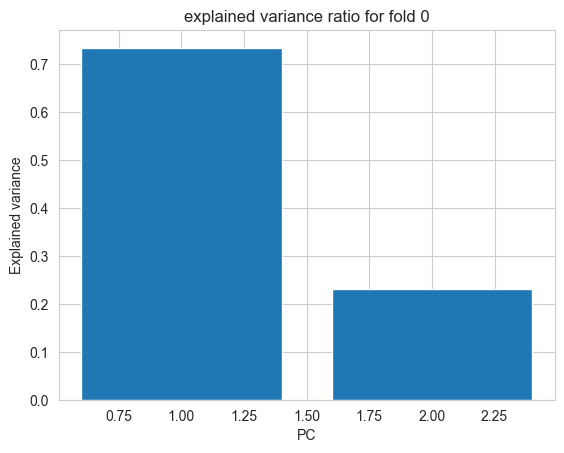

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


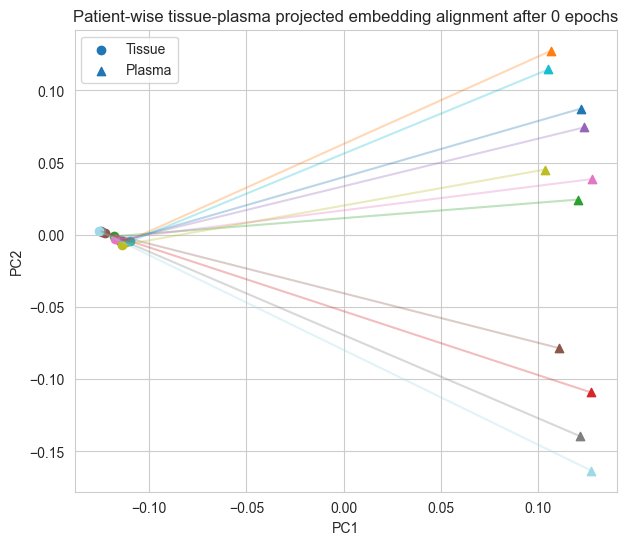

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


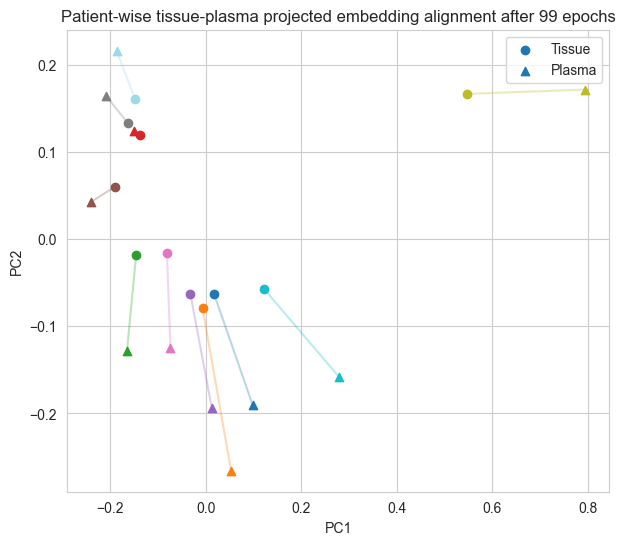

PC1 0.5041322314049587
PC2 0.4297520661157025
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.068129      0.075019     1
1  PC2       0.096485      0.067172     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.048606    -0.024303     0.024303     1
1  PC2             0.077730     0.038865    -0.038865     1


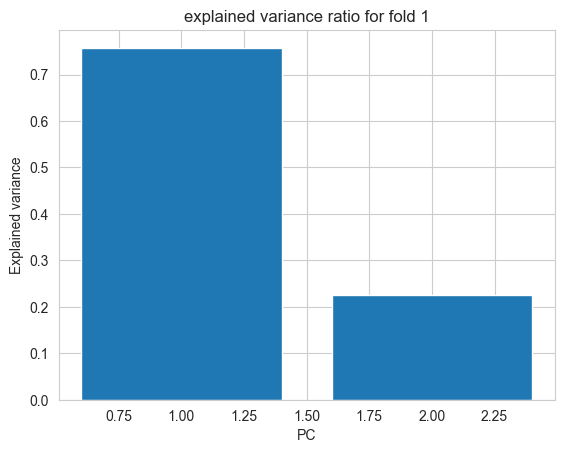

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


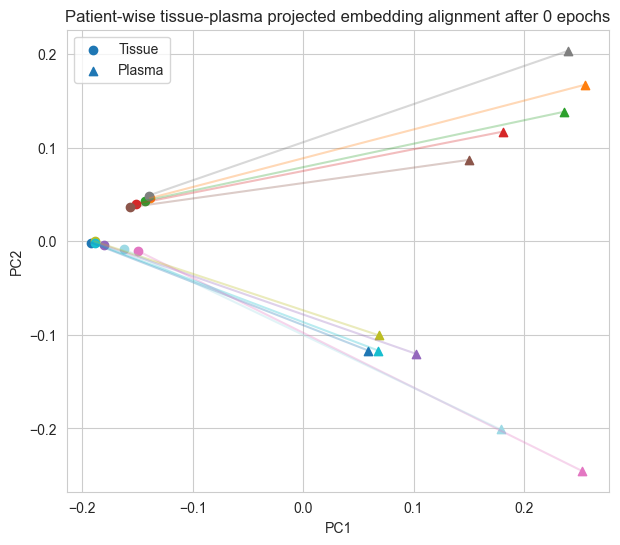

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


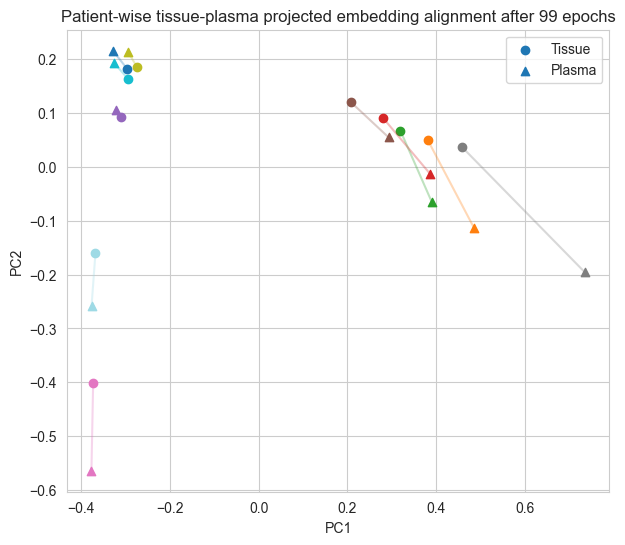

PC1 0.63
PC2 0.53
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       0.043365      0.018570     2
1  PC2       0.023124      0.019384     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.029644    -0.014822     0.014822     2
1  PC2             0.008077    -0.004039     0.004039     2


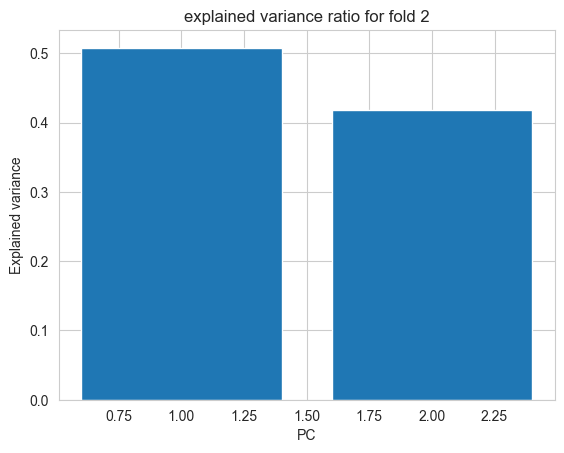

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


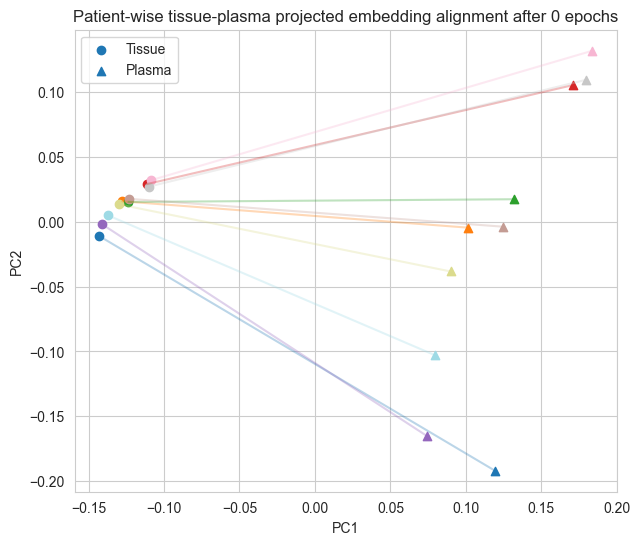

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


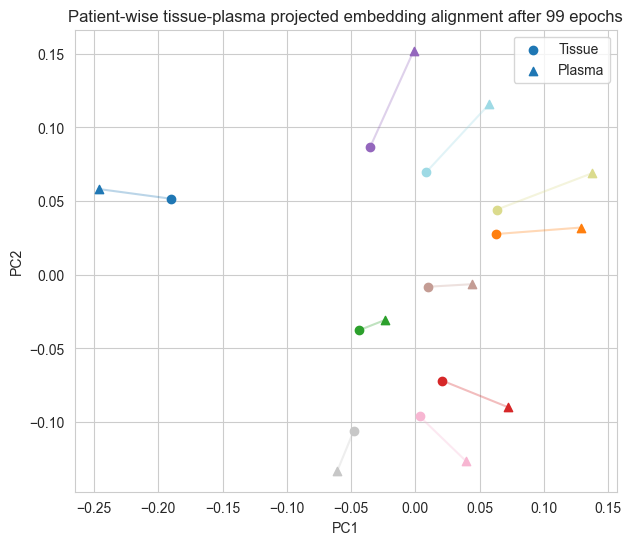

PC1 0.54
PC2 0.58
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       0.072094       0.04934     3
1  PC2       0.037491       0.03330     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.026472     0.013236    -0.013236     3
1  PC2             0.031887    -0.015943     0.015943     3


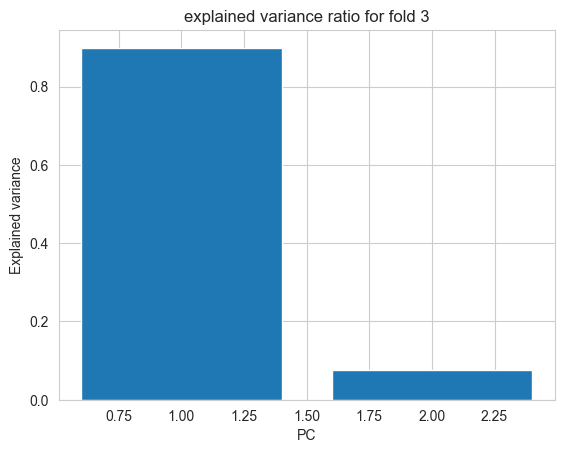

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


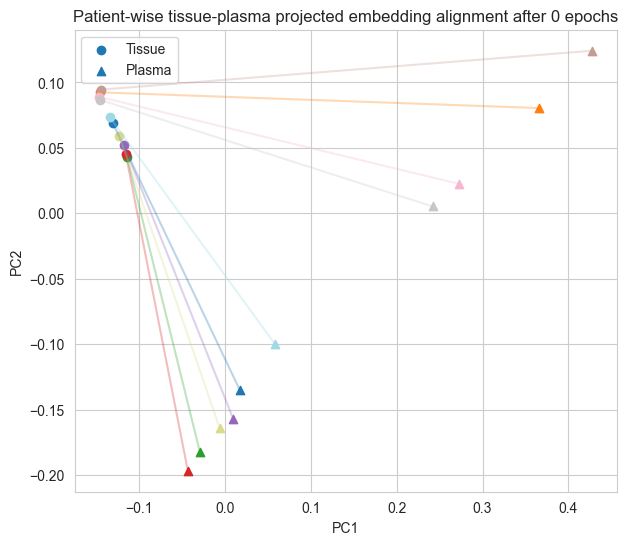

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


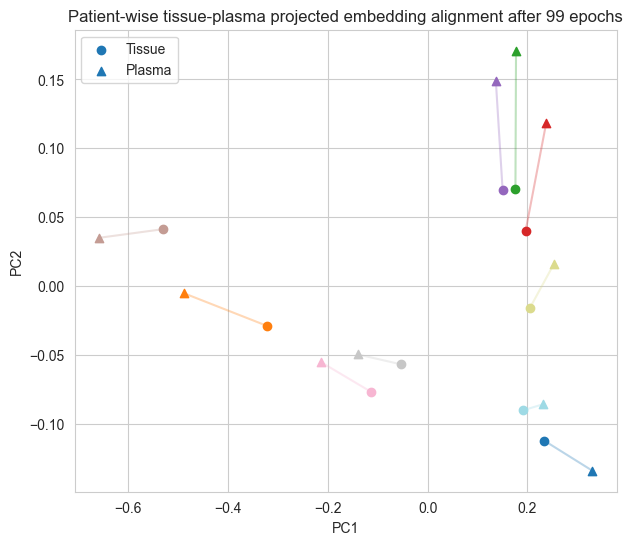

PC1 0.6
PC2 0.37
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.086671      0.029092     4
1  PC2       0.112217      0.084498     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.030256    -0.015128     0.015128     4
1  PC2             0.108242     0.054121    -0.054121     4


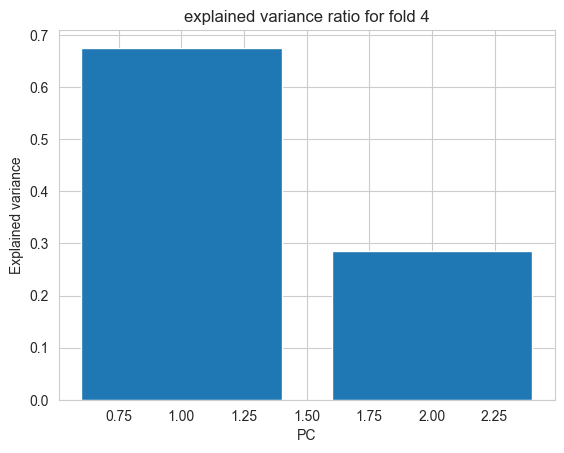

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


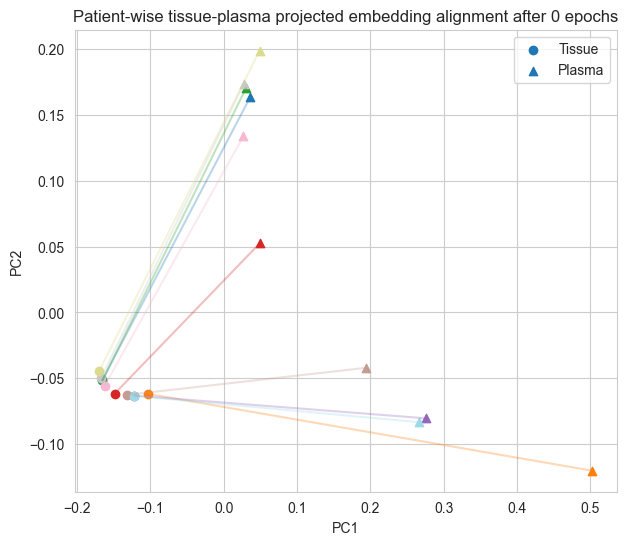

C:\Users\P095551\AppData\Local\Temp\ipykernel_21056\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


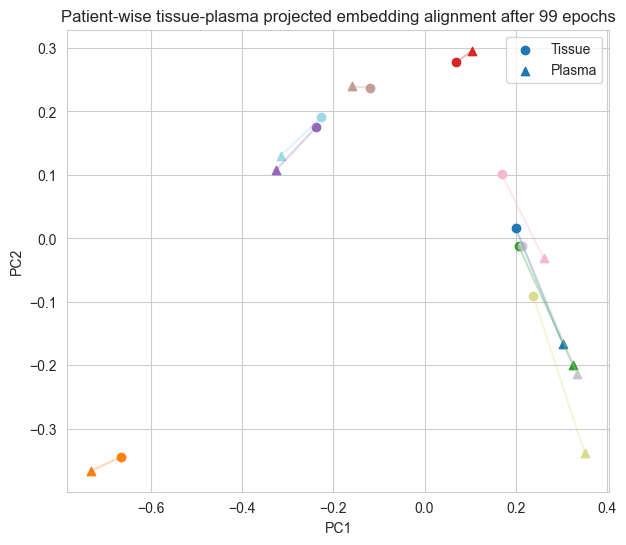

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue  0.017644 -0.062865     0
1    Sample 15   Plasma  0.098205 -0.189830     0
2    Sample 17   Tissue -0.006294 -0.079543     0
3    Sample 17   Plasma  0.053302 -0.265687     0
4    Sample 28   Tissue -0.145562 -0.018652     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  0.335160 -0.213124     4
100  Sample 77   Tissue  0.238595 -0.090269     4
101  Sample 77   Plasma  0.351634 -0.338381     4
102  Sample 90   Tissue -0.226729  0.190697     4
103  Sample 90   Plasma -0.316056  0.130079     4

[104 rows x 5 columns]


In [161]:
pc, all_distances, all_separations, all_variance = visualize_embeddings(proj=True, trained=True)

In [162]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.017644 -0.062865     0
1  Sample 15   Plasma  0.098205 -0.189830     0
2  Sample 17   Tissue -0.006294 -0.079543     0
3  Sample 17   Plasma  0.053302 -0.265687     0
4  Sample 28   Tissue -0.145562 -0.018652     0


In [163]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    0.067851                   0.048085
1  PC2                    0.069798                   0.052407


In [164]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      0.034864
1  PC2                      0.057648


In [165]:
print(all_distances)

    PC  mean_distance  std_distance  fold
0  PC1       0.068995      0.068403     0
1  PC2       0.079672      0.057680     0
2  PC1       0.068129      0.075019     1
3  PC2       0.096485      0.067172     1
4  PC1       0.043365      0.018570     2
5  PC2       0.023124      0.019384     2
6  PC1       0.072094      0.049340     3
7  PC2       0.037491      0.033300     3
8  PC1       0.086671      0.029092     4
9  PC2       0.112217      0.084498     4


In [166]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.715167      0.141857
1  PC2       0.246998      0.123481


In [167]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')
plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [168]:
tissue_scores.columns

Index(['Name', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT',
       'REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS',
       'REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS',
       'REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       ...
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS',
       'REACTOME_VEGFR

In [169]:
pathways_1 = set(tissue_scores.columns).intersection(plasma_scores.columns) 
pathways_1.remove('patient')
print(pathways_1)

KeyError: 'patient'

In [170]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.017644 -0.062865     0
1  Sample 15   Plasma  0.098205 -0.189830     0
2  Sample 17   Tissue -0.006294 -0.079543     0
3  Sample 17   Plasma  0.053302 -0.265687     0
4  Sample 28   Tissue -0.145562 -0.018652     0


In [171]:
from scipy.stats import pearsonr, spearmanr
merged = tissue_scores.merge(
    plasma_scores,
    on="patient",
    suffixes=("_tissue", "_plasma")
)

results = []

for pathway in pathways_1:

    tissue_col = f"{pathway}_tissue"
    plasma_col = f"{pathway}_plasma"

    # Only keep patients with both scores
    valid = merged[[tissue_col, plasma_col]].dropna()

    if len(valid) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        valid[tissue_col],
        valid[plasma_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[tissue_col],
        valid[plasma_col]
    )

    results.append({
        "pathway": pathway,
        "n": len(valid),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

pathway_correlations = pd.DataFrame(results)


KeyError: 'patient'

In [172]:
print(pathway_correlations)

                                               pathway   n  pearson_r  \
0    REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_R...  52   0.146067   
1     REACTOME_APOPTOTIC_CLEAVAGE_OF_CELLULAR_PROTEINS  52   0.040940   
2    REACTOME_SIGNALING_BY_MODERATE_KINASE_ACTIVITY...  52   0.052160   
3    REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...  52  -0.107435   
4    REACTOME_ANTIGEN_PROCESSING_UBIQUITINATION_PRO...  52  -0.070677   
..                                                 ...  ..        ...   
304                           REACTOME_UCH_PROTEINASES  52  -0.016270   
305  REACTOME_INTRINSIC_PATHWAY_OF_FIBRIN_CLOT_FORM...  52   0.155597   
306                        REACTOME_CELL_CYCLE_MITOTIC  52   0.258215   
307           REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS  52  -0.061890   
308          REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES  52   0.006025   

     pearson_p  spearman_r  spearman_p  
0     0.301485    0.057201    0.687104  
1     0.773220   -0.011696    0.934411  


In [173]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.017644 -0.062865     0
2  Sample 17   Tissue -0.006294 -0.079543     0
4  Sample 28   Tissue -0.145562 -0.018652     0
6  Sample 29   Tissue -0.137235  0.119316     0
8  Sample 34   Tissue -0.031901 -0.062717     0
     patient modality       PC1       PC2  fold
1  Sample 15   Plasma  0.098205 -0.189830     0
3  Sample 17   Plasma  0.053302 -0.265687     0
5  Sample 28   Plasma -0.164712 -0.128584     0
7  Sample 29   Plasma -0.149998  0.124097     0
9  Sample 34   Plasma  0.013077 -0.194255     0


In [174]:
print(merged_tissue)

      patient modality       PC1       PC2  fold  \
0   Sample 15   Tissue  0.017644 -0.062865     0   
1   Sample 17   Tissue -0.006294 -0.079543     0   
2   Sample 28   Tissue -0.145562 -0.018652     0   
3   Sample 29   Tissue -0.137235  0.119316     0   
4   Sample 34   Tissue -0.031901 -0.062717     0   
5   Sample 38   Tissue -0.190667  0.059800     0   
6   Sample 61   Tissue -0.080890 -0.016203     0   
7   Sample 76   Tissue -0.163128  0.133106     0   
8   Sample 78   Tissue  0.547475  0.166566     0   
9   Sample 85   Tissue  0.122286 -0.057097     0   
10  Sample 88   Tissue -0.148101  0.160952     0   
11  Sample 16   Tissue -0.296229  0.181922     1   
12  Sample 18   Tissue  0.381567  0.049041     1   
13  Sample 22   Tissue  0.319550  0.067009     1   
14  Sample 31   Tissue  0.279686  0.091470     1   
15  Sample 49   Tissue -0.309128  0.092580     1   
16  Sample 51   Tissue  0.207857  0.120161     1   
17  Sample 64   Tissue -0.372928 -0.400654     1   
18  Sample 6

In [175]:
from scipy.stats import pearsonr, spearmanr


def correlate_pc_pathways(df, pc_cols=("PC1", "PC2")):
    results = []

    # pathway columns = everything except metadata + PCs
    metadata = {"patient", "modality", "fold", "Name"}
    pathway_cols = [
        col for col in df.columns
        if col not in metadata and col not in pc_cols
    ]

    for pc in pc_cols:
        for pathway in pathway_cols:

            # Remove missing values for this particular pair
            valid = df[[pc, pathway]].dropna()

            if len(valid) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid[pc],
                valid[pathway]
            )

            spearman_r, spearman_p = spearmanr(
                valid[pc],
                valid[pathway]
            )

            results.append({
                "PC": pc,
                "pathway": pathway,
                "n": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [176]:
from statsmodels.stats.multitest import multipletests

def add_fdr(results):

    results = results.copy()

    results["pearson_fdr"] = multipletests(
        results["pearson_p"],
        method="fdr_bh"
    )[1]

    results["spearman_fdr"] = multipletests(
        results["spearman_p"],
        method="fdr_bh"
    )[1]

    return results

In [177]:
tissue_results = []

for fold in range(5):

    fold_df = merged_tissue[
        merged_tissue["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    tissue_results.append(result)

tissue_results = pd.concat(
    tissue_results,
    ignore_index=True
)

tissue_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
6900,PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.911477,0.000241,0.939394,0.000055,4
643,PC1,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,0.871430,0.000475,0.863636,0.000612,0
1949,PC1,REACTOME_METABOLISM_OF_STEROIDS,11,0.857757,0.000733,0.736364,0.009760,1
6901,PC1,REACTOME_RND3_GTPASE_CYCLE,10,0.854432,0.001642,0.781818,0.007547,4
7579,PC2,REACTOME_PROCESSING_OF_INTRONLESS_PRE_MRNAS,10,0.841260,0.002283,0.806061,0.004862,4
3279,PC1,REACTOME_DAP12_SIGNALING,10,0.827369,0.003137,0.684848,0.028883,2
131,PC1,REACTOME_DAP12_SIGNALING,11,0.818199,0.002082,0.863636,0.000612,0
6533,PC1,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,0.815019,0.004071,0.866667,0.001174,4
1850,PC1,REACTOME_G_PROTEIN_BETA_GAMMA_SIGNALLING,11,0.814517,0.002266,0.790909,0.003746,1
3810,PC1,REACTOME_SIGNALING_BY_INTERLEUKINS,10,0.811994,0.004327,0.648485,0.042540,2


In [178]:
plasma_results = []

for fold in range(5):

    fold_df = merged_plasma[
        merged_plasma["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    plasma_results.append(result)

plasma_results = pd.concat(
    plasma_results,
    ignore_index=True
)
plasma_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
2780,PC1,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.976804,1.231637e-06,0.878788,0.000814,4
2585,PC1,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.976028,1.403508e-06,0.939394,0.000055,4
2575,PC1,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,10,0.974390,1.824883e-06,0.866667,0.001174,4
690,PC1,REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT...,11,0.971707,6.057132e-07,0.809091,0.002559,1
2623,PC1,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,0.969948,3.441096e-06,0.818182,0.003815,4
2632,PC1,REACTOME_EPHB_MEDIATED_FORWARD_SIGNALING,10,0.969675,3.566666e-06,0.878788,0.000814,4
2633,PC1,REACTOME_EPH_EPHRIN_SIGNALING,10,0.967883,4.477816e-06,0.903030,0.000344,4
872,PC1,REACTOME_RHOBTB_GTPASE_CYCLE,11,0.966391,1.304439e-06,0.772727,0.005299,1
723,PC1,REACTOME_DNA_REPAIR,11,0.963506,1.881830e-06,0.800000,0.003110,1
699,PC1,REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,11,0.961307,2.440674e-06,0.954545,0.000005,1


#### Cross modality pathway correlation

In [179]:
### Correlate tissue pc values with plasma pathway scores 
plasma_pathways = plasma_scores.copy()
tissue_pc_plasma_pathways = tissue_pc.merge(
    plasma_pathways,
    on="patient",
    how="inner"
)
cross_tissue_to_plasma = []

for fold in range(5):

    fold_df = tissue_pc_plasma_pathways[
        tissue_pc_plasma_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_tissue_to_plasma.append(result)

cross_tissue_to_plasma = pd.concat(
    cross_tissue_to_plasma,
    ignore_index=True
)
cross_tissue_to_plasma.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
2585,PC1,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.980310,6.421930e-07,0.939394,5.484053e-05,4
690,PC1,REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT...,11,0.978627,1.731686e-07,0.845455,1.045182e-03,1
2623,PC1,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,0.975059,1.642747e-06,0.818182,3.814920e-03,4
879,PC1,REACTOME_RHO_GTPASE_CYCLE,11,0.972305,5.507137e-07,0.800000,3.110428e-03,1
795,PC1,REACTOME_MEMBRANE_TRAFFICKING,11,0.971680,6.083238e-07,0.854545,8.066742e-04,1
872,PC1,REACTOME_RHOBTB_GTPASE_CYCLE,11,0.971640,6.121929e-07,0.827273,1.676974e-03,1
846,PC1,REACTOME_RAC1_GTPASE_CYCLE,11,0.970018,7.844487e-07,0.836364,1.333185e-03,1
699,PC1,REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,11,0.969436,8.545250e-07,0.990909,3.762572e-09,1
840,PC1,REACTOME_PROTEIN_FOLDING,11,0.969163,8.891473e-07,0.854545,8.066742e-04,1
2719,PC1,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,10,0.968869,3.957732e-06,0.830303,2.940227e-03,4


In [180]:
### Correlate plasma embedding/PC scores with tissue pathway scores
#### this is the important one
tissue_pathways = tissue_scores.copy()
plasma_pc_tissue_pathways = plasma_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

cross_plasma_to_tissue = []

for fold in range(5):

    fold_df = plasma_pc_tissue_pathways[
        plasma_pc_tissue_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_plasma_to_tissue.append(result)

cross_plasma_to_tissue = pd.concat(
    cross_plasma_to_tissue,
    ignore_index=True
)


In [181]:
tissue_results = add_fdr(tissue_results)
plasma_results = add_fdr(plasma_results)

cross_tissue_to_plasma = add_fdr(cross_tissue_to_plasma)
cross_plasma_to_tissue = add_fdr(cross_plasma_to_tissue)

In [209]:
cross_plasma_to_tissue.sort_values(
    ["pearson_fdr",'spearman_fdr'],
    ascending=True
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
6900,PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.942483,0.000045,0.939394,0.000055,4,0.351432,0.431595
643,PC1,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,0.887129,0.000271,0.863636,0.000612,0,0.532398,0.432925
1949,PC1,REACTOME_METABOLISM_OF_STEROIDS,11,0.892266,0.000221,0.800000,0.003110,1,0.532398,0.556343
423,PC1,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,11,-0.890313,0.000239,-0.736364,0.009760,0,0.532398,0.667892
131,PC1,REACTOME_DAP12_SIGNALING,11,0.848756,0.000953,0.863636,0.000612,0,0.878549,0.432925
330,PC1,REACTOME_INTERLEUKIN_3_INTERLEUKIN_5_AND_GM_CS...,11,0.616642,0.043314,0.890909,0.000233,0,0.878549,0.432925
548,PC1,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,0.771212,0.005447,0.881818,0.000330,0,0.878549,0.432925
724,PC1,REACTOME_TCR_SIGNALING,11,0.765817,0.005999,0.854545,0.000807,0,0.878549,0.432925
748,PC1,REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX3,11,0.718307,0.012777,0.845455,0.001045,0,0.878549,0.432925
1777,PC1,REACTOME_ERCC6_CSB_AND_EHMT2_G9A_POSITIVELY_RE...,11,0.651109,0.030010,0.845455,0.001045,1,0.878549,0.432925


In [183]:
summary_plasma_to_tissue = (
    cross_plasma_to_tissue
    .groupby(["PC", "pathway"])
    .agg(
        # Pearson
        pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()),
        pearson_median_abs_r=("pearson_r", lambda x: x.abs().median()),
        pearson_min_abs_r=("pearson_r", lambda x: x.abs().min()),
        pearson_max_abs_r=("pearson_r", lambda x: x.abs().max()),

        # Spearman
        spearman_mean_abs_r=("spearman_r", lambda x: x.abs().mean()),
        spearman_median_abs_r=("spearman_r", lambda x: x.abs().median()),
        spearman_min_abs_r=("spearman_r", lambda x: x.abs().min()),
        spearman_max_abs_r=("spearman_r", lambda x: x.abs().max()),

        n_folds=("fold", "nunique"),
    )
    .reset_index()
)

print(summary_plasma_to_tissue)

       PC                                            pathway  \
0     PC1    REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT   
1     PC1                 REACTOME_ABC_TRANSPORTER_DISORDERS   
2     PC1  REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...   
3     PC1   REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS   
4     PC1  REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...   
...   ...                                                ...   
1569  PC2  REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOM...   
1570  PC2     REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY   
1571  PC2      REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G   
1572  PC2             REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS   
1573  PC2                  REACTOME_VISUAL_PHOTOTRANSDUCTION   

      pearson_mean_abs_r  pearson_median_abs_r  pearson_min_abs_r  \
0               0.238048              0.109712           0.002806   
1               0.277004              0.313687           0.026477   
2               0.337611

In [184]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(10)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1480,PC2,REACTOME_SMOOTH_MUSCLE_CONTRACTION,0.462981,0.427663,0.257785,0.658164,0.387273,0.393939,0.136364,0.551515,5
902,PC2,REACTOME_CO_INHIBITION_BY_CTLA4,0.447719,0.474198,0.122358,0.681457,0.522424,0.554545,0.393939,0.645455,5
1224,PC2,REACTOME_NRAGE_SIGNALS_DEATH_THROUGH_JNK,0.438573,0.445220,0.070897,0.772833,0.396364,0.318182,0.154545,0.757576,5
871,PC2,REACTOME_CELL_EXTRACELLULAR_MATRIX_INTERACTIONS,0.431747,0.472947,0.217635,0.594043,0.332727,0.327273,0.018182,0.539394,5
1473,PC2,REACTOME_SIGNALING_BY_VEGF,0.426619,0.388732,0.179441,0.744682,0.374545,0.400000,0.006061,0.696970,5
1273,PC2,REACTOME_PLATELET_SENSITIZATION_BY_LDL,0.419690,0.442635,0.164270,0.717878,0.386061,0.442424,0.200000,0.515152,5
923,PC2,REACTOME_DEATH_RECEPTOR_SIGNALING,0.419185,0.381591,0.105210,0.708862,0.358182,0.327273,0.100000,0.600000,5
1369,PC2,REACTOME_RHO_GTPASES_ACTIVATE_CIT,0.418209,0.424561,0.196023,0.715888,0.373333,0.357576,0.063636,0.672727,5
1258,PC2,REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS,0.417806,0.450573,0.173906,0.581046,0.296970,0.272727,0.078788,0.490909,5
1195,PC2,REACTOME_MUSCLE_CONTRACTION,0.417015,0.395511,0.226612,0.638186,0.383030,0.372727,0.139394,0.587879,5


In [210]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(15)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
299,PC1,REACTOME_HSF1_DEPENDENT_TRANSACTIVATION,0.604048,0.615873,0.358101,0.796938,0.500000,0.466667,0.151515,0.745455,5
237,PC1,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.599783,0.651257,0.251394,0.820967,0.518788,0.406061,0.103030,0.866667,5
44,PC1,REACTOME_ATTENUATION_PHASE,0.598807,0.729664,0.285173,0.850475,0.496364,0.466667,0.236364,0.745455,5
130,PC1,REACTOME_DAP12_INTERACTIONS,0.597075,0.772984,0.131256,0.831997,0.618788,0.745455,0.187879,0.878788,5
131,PC1,REACTOME_DAP12_SIGNALING,0.579423,0.817640,0.031012,0.848756,0.581212,0.672727,0.030303,0.863636,5
301,PC1,REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN...,0.549653,0.533501,0.496732,0.623680,0.430303,0.418182,0.260606,0.618182,5
681,PC1,REACTOME_SIGNALING_BY_TGFBR3,0.548930,0.699811,0.028565,0.791608,0.547879,0.612121,0.236364,0.818182,5
587,PC1,REACTOME_RHO_GTPASES_ACTIVATE_PKNS,0.524519,0.425090,0.342985,0.797547,0.489091,0.436364,0.272727,0.757576,5
455,PC1,REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE,0.522468,0.578730,0.381805,0.677011,0.463030,0.527273,0.018182,0.696970,5
515,PC1,REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PRO...,0.519456,0.513685,0.218512,0.712482,0.454545,0.436364,0.115152,0.757576,5


In [213]:
top_pearson = summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(15)['pathway'].tolist()

In [214]:
print(top_pearson)

['REACTOME_HSF1_DEPENDENT_TRANSACTIVATION', 'REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC', 'REACTOME_ATTENUATION_PHASE', 'REACTOME_DAP12_INTERACTIONS', 'REACTOME_DAP12_SIGNALING', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_RHO_GTPASES_ACTIVATE_PKNS', 'REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE', 'REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PROTEINS_AND_COMPLEXES', 'REACTOME_AURKA_ACTIVATION_BY_TPX2', 'REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_TRANSITION', 'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_SIGNALING_BY_INTERLEUKINS', 'REACTOME_FC_EPSILON_RECEPTOR_FCERI_SIGNALING']


In [215]:
tissue_pc_plasma_pathways.head()

,patient,modality,PC1,PC2,fold,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,...,REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VESICLE_MEDIATED_TRANSPORT,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_INFECTION_PATHWAYS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 15,Tissue,0.017644,-0.062865,0,0.204250,0.214317,0.168489,0.149088,0.164303,...,-0.035744,0.168489,0.138505,0.100617,0.159640,0.036210,0.158433,0.128664,0.195283,0.390870
1,Sample 17,Tissue,-0.006294,-0.079543,0,0.026838,0.033465,-0.005519,-0.004788,0.180325,...,0.033403,-0.005519,-0.012768,-0.019499,0.016425,0.078718,0.205294,-0.021473,0.191556,0.366004
2,Sample 28,Tissue,-0.145562,-0.018652,0,0.159901,0.154310,0.112480,0.114566,0.221838,...,0.086650,0.112480,0.113977,0.100253,0.133214,0.133493,0.229199,0.124562,0.231783,0.271223
3,Sample 29,Tissue,-0.137235,0.119316,0,0.268874,0.266008,0.248693,0.235441,0.238812,...,0.123468,0.248693,0.225208,0.225463,0.243030,0.165831,0.241994,0.221681,0.262423,0.164421
4,Sample 34,Tissue,-0.031901,-0.062717,0,0.197636,0.194783,0.152219,0.132832,0.164300,...,-0.043331,0.152219,0.128396,0.087808,0.139243,0.115290,0.159399,0.118255,0.220068,0.403327


In [216]:
top_pearson_PC1 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
    #.index
)
top_pearson_PC1_index = top_pearson_PC1[(top_pearson_PC1["mean_abs_r"] > 0.45)].index
top_pearson_PC2 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
   # .index
)
top_pearson_PC2_index = top_pearson_PC2[(top_pearson_PC2["mean_abs_r"] > 0.45)].index
print(top_pearson_PC1_index)
print(top_pearson_PC2_index)

plot_data_PC2 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC2_index))
].copy()

plot_data_PC2["abs_pearson_r"] = plot_data_PC2["pearson_r"].abs()

plot_df_PC2 = plot_data_PC2.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC2

Index(['REACTOME_HSF1_DEPENDENT_TRANSACTIVATION',
       'REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC',
       'REACTOME_ATTENUATION_PHASE', 'REACTOME_DAP12_INTERACTIONS',
       'REACTOME_DAP12_SIGNALING',
       'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL',
       'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_RHO_GTPASES_ACTIVATE_PKNS',
       'REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE',
       'REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PROTEINS_AND_COMPLEXES'],
      dtype='str', name='pathway')
Index(['REACTOME_SMOOTH_MUSCLE_CONTRACTION'], dtype='str', name='pathway')


fold,0,1,2,3,4
pathway,,,,,
REACTOME_SMOOTH_MUSCLE_CONTRACTION,0.257785,0.427663,0.554843,0.416453,0.658164


In [217]:
plot_data_PC1 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC1") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC1_index))
].copy()

plot_data_PC1["abs_pearson_r"] = plot_data_PC1["pearson_r"].abs()

plot_df_PC1 = plot_data_PC1.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC1

fold,0,1,2,3,4
pathway,,,,,
REACTOME_ATTENUATION_PHASE,0.850475,0.392128,0.285173,0.736594,0.729664
REACTOME_DAP12_INTERACTIONS,0.826808,0.422332,0.772984,0.131256,0.831997
REACTOME_DAP12_SIGNALING,0.848756,0.378077,0.821632,0.031012,0.817640
REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC,0.757566,0.517731,0.651257,0.251394,0.820967
REACTOME_HSF1_DEPENDENT_TRANSACTIVATION,0.796938,0.358101,0.592852,0.615873,0.656477
REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL,0.587045,0.533501,0.507308,0.623680,0.496732
REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE,0.677011,0.578730,0.381805,0.387527,0.587268
REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PROTEINS_AND_COMPLEXES,0.650030,0.513685,0.502572,0.218512,0.712482
REACTOME_RHO_GTPASES_ACTIVATE_PKNS,0.652042,0.425090,0.404932,0.342985,0.797547


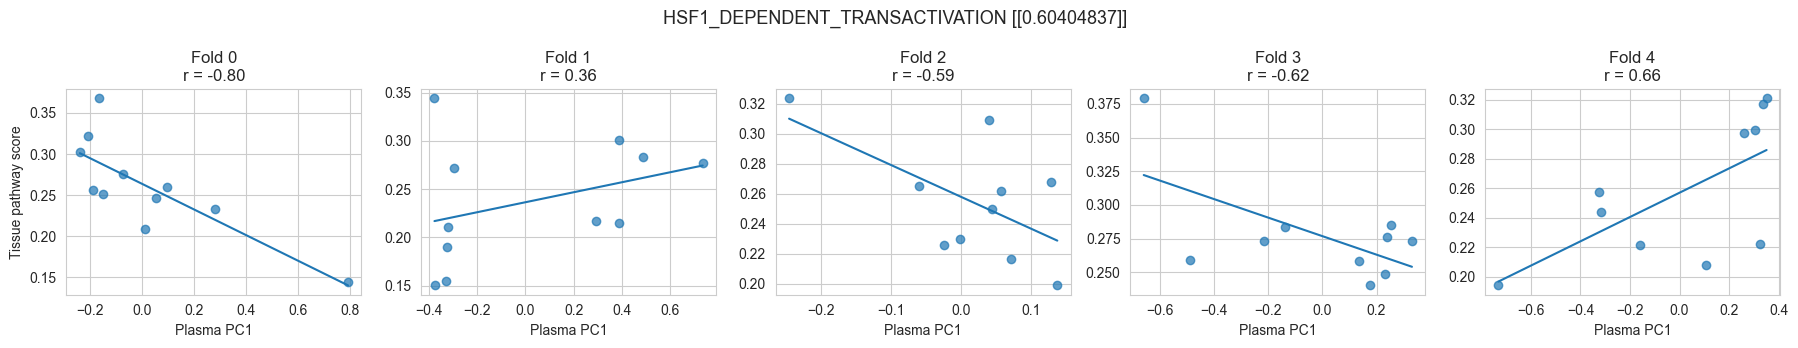

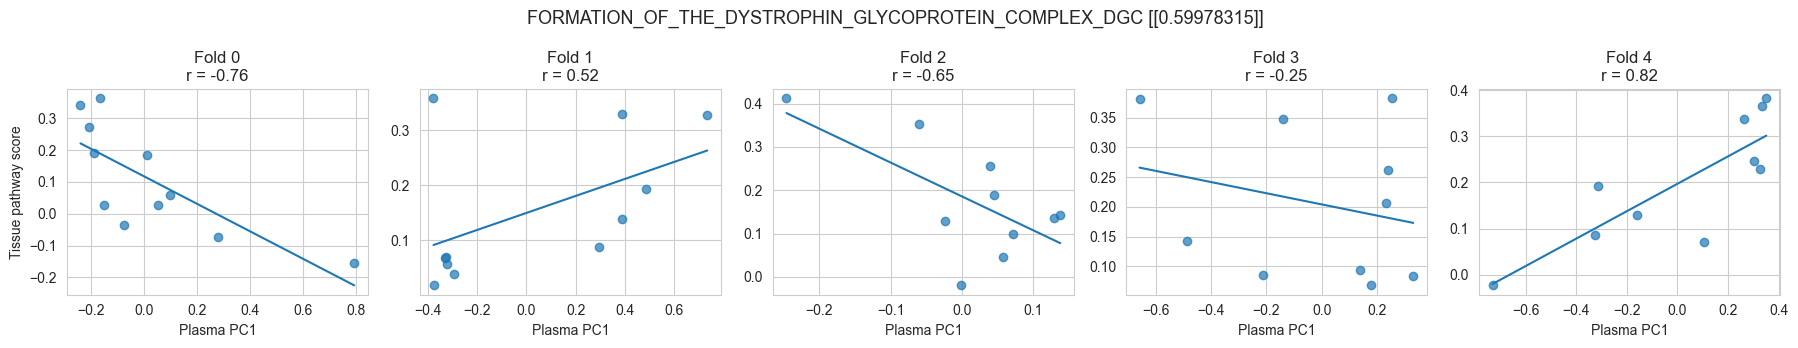

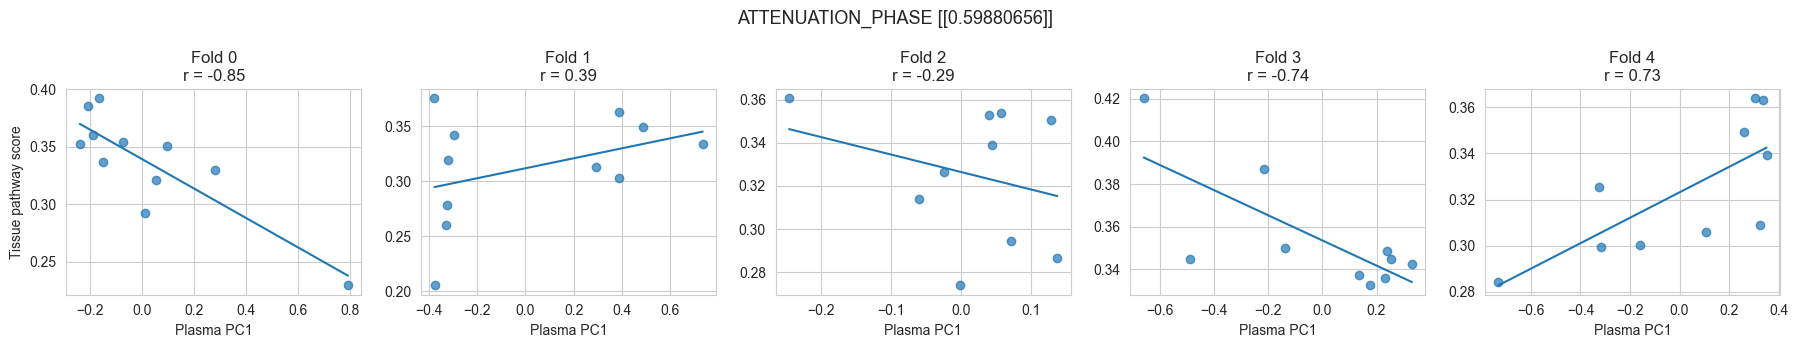

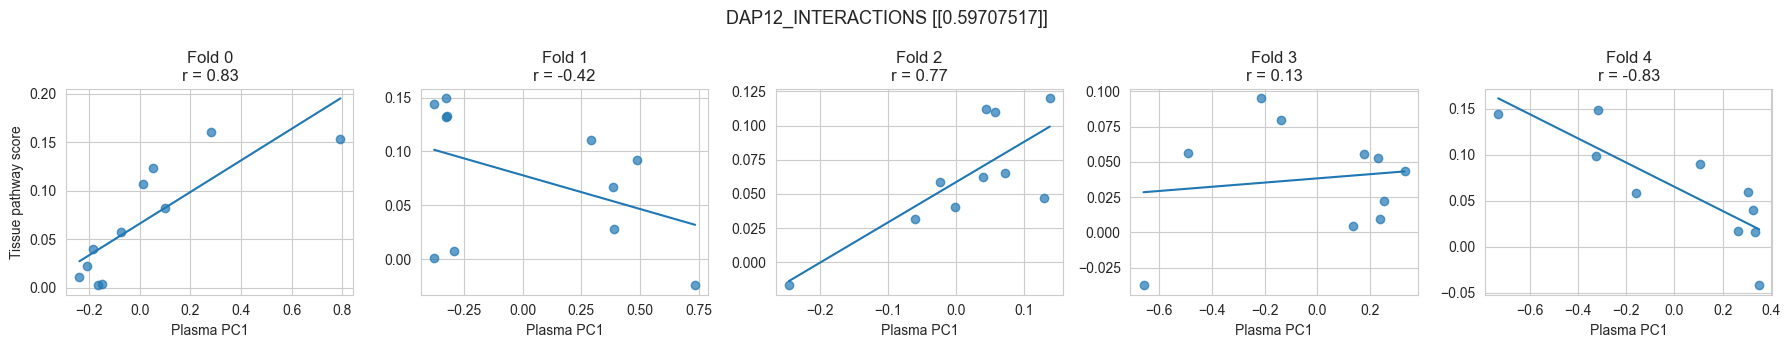

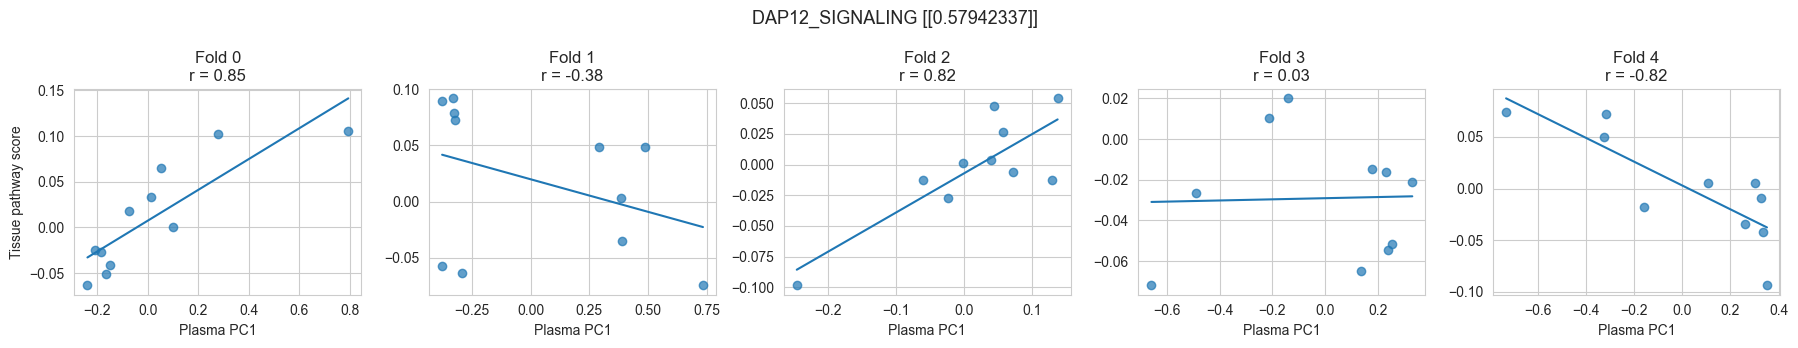

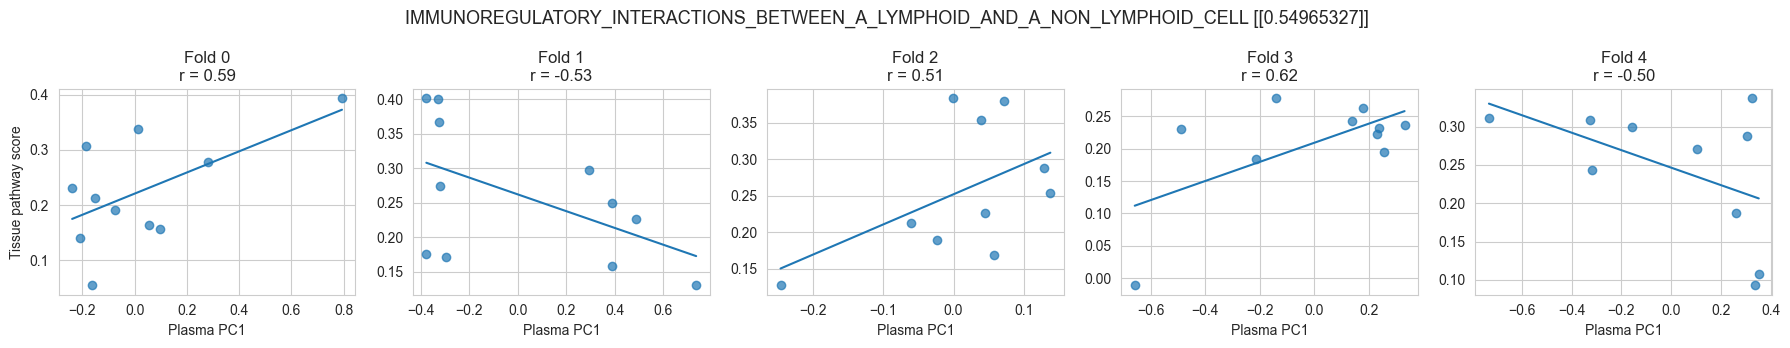

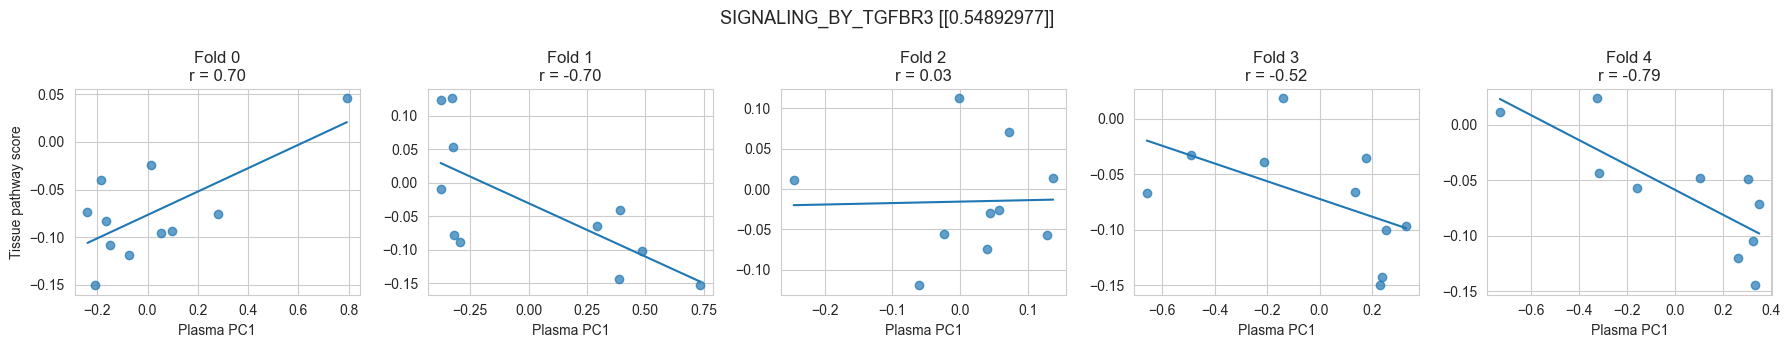

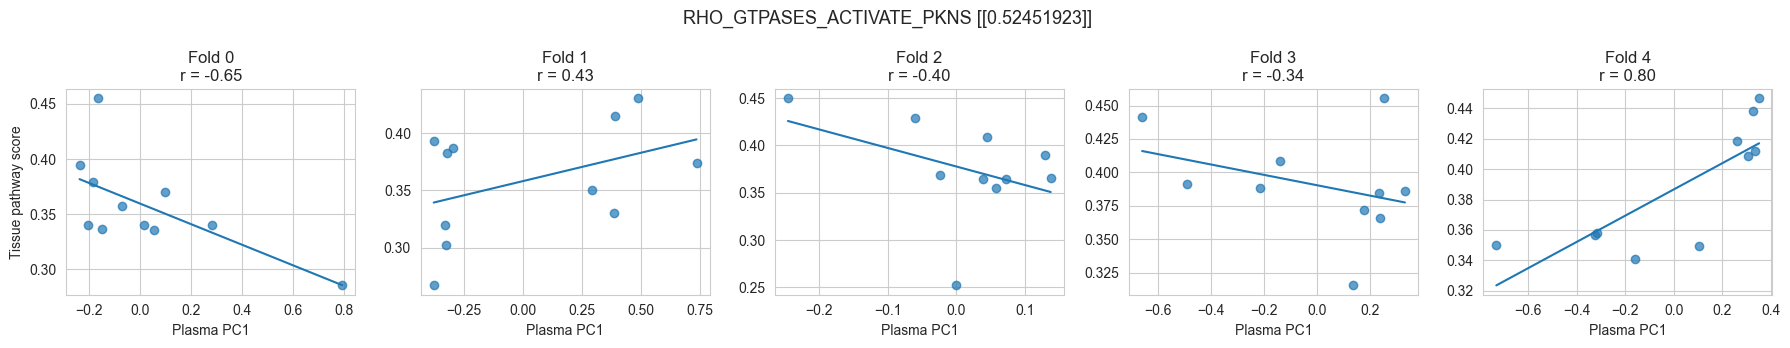

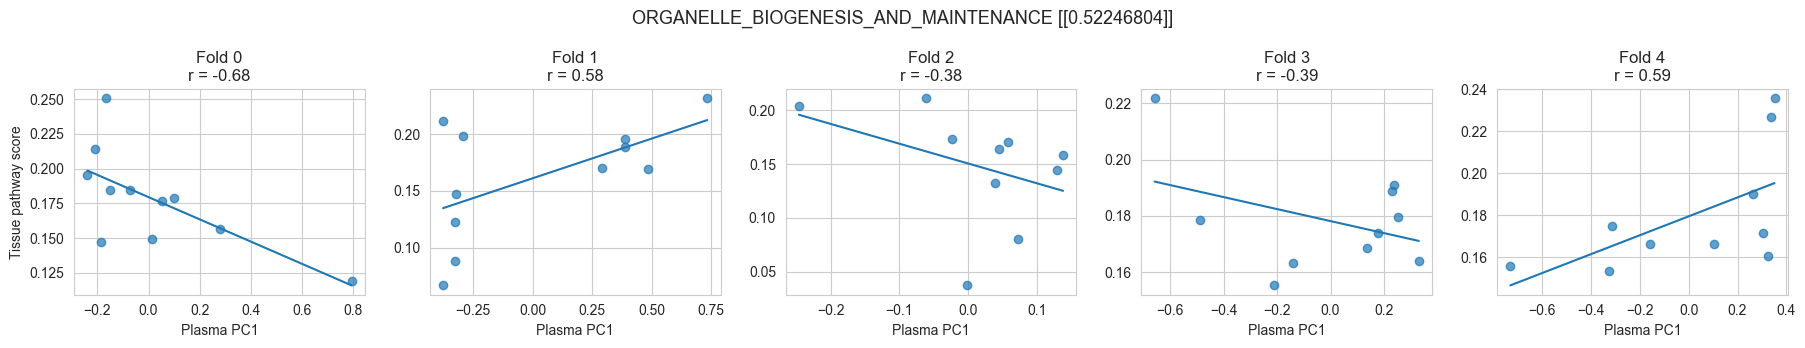

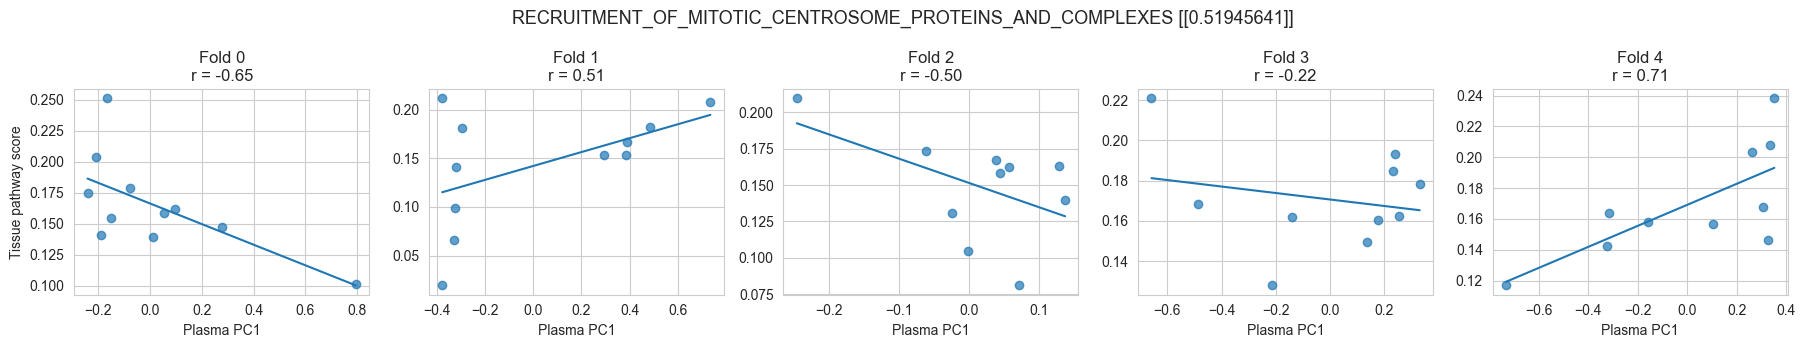

In [218]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC1_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC1") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC1"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC1")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

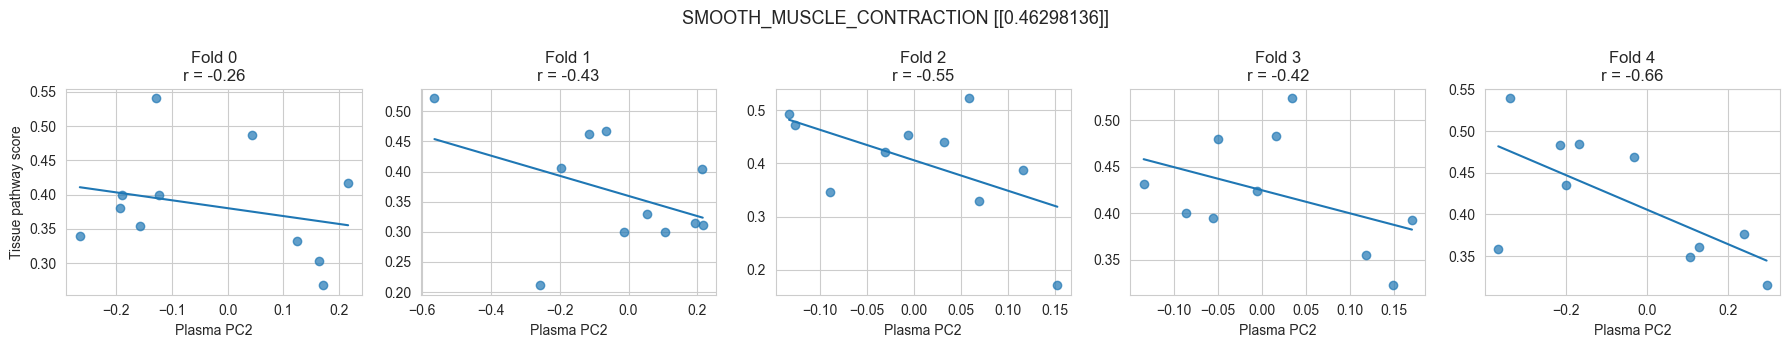

In [219]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC2_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC2"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC2")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

In [220]:
print(top_pearson)

['REACTOME_HSF1_DEPENDENT_TRANSACTIVATION', 'REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC', 'REACTOME_ATTENUATION_PHASE', 'REACTOME_DAP12_INTERACTIONS', 'REACTOME_DAP12_SIGNALING', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_RHO_GTPASES_ACTIVATE_PKNS', 'REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE', 'REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PROTEINS_AND_COMPLEXES', 'REACTOME_AURKA_ACTIVATION_BY_TPX2', 'REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_TRANSITION', 'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_SIGNALING_BY_INTERLEUKINS', 'REACTOME_FC_EPSILON_RECEPTOR_FCERI_SIGNALING']


In [ ]:
print(type(top_pearson))
print(type(pathway_correlations))
print(pathway_correlations.head())

In [211]:
pathway_comp = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC1") &
        (cross_plasma_to_tissue["pathway"].isin(top_pearson))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)

pathway_correlations_1 = pathway_correlations[
    pathway_correlations["pathway"].isin(top_pearson)
][["pathway", "pearson_r"]]

pathway_comp = pathway_comp.merge(
    pathway_correlations_1,
    on="pathway",
    how="left"
)

pathway_comp = pathway_comp.rename(columns={
    "pc_pathway_abs_r": "PC2 plasma → tissue pathway |r|",
    "pearson_r": "Plasma pathway ↔ tissue pathway r"
})

print(pathway_comp.head(10))

                                             pathway  \
0                         REACTOME_ATTENUATION_PHASE   
1                        REACTOME_DAP12_INTERACTIONS   
2                           REACTOME_DAP12_SIGNALING   
3  REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...   
4            REACTOME_HSF1_DEPENDENT_TRANSACTIVATION   

   PC2 plasma → tissue pathway |r|  Plasma pathway ↔ tissue pathway r  
0                         0.598807                                NaN  
1                         0.597075                                NaN  
2                         0.579423                                NaN  
3                         0.599783                                NaN  
4                         0.604048                                NaN  


In [212]:
pathway_comp.head(10)

,pathway,PC2 plasma → tissue pathway |r|,Plasma pathway ↔ tissue pathway r
0,REACTOME_ATTENUATION_PHASE,0.598807,NaN
1,REACTOME_DAP12_INTERACTIONS,0.597075,NaN
2,REACTOME_DAP12_SIGNALING,0.579423,NaN
3,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.599783,NaN
4,REACTOME_HSF1_DEPENDENT_TRANSACTIVATION,0.604048,NaN


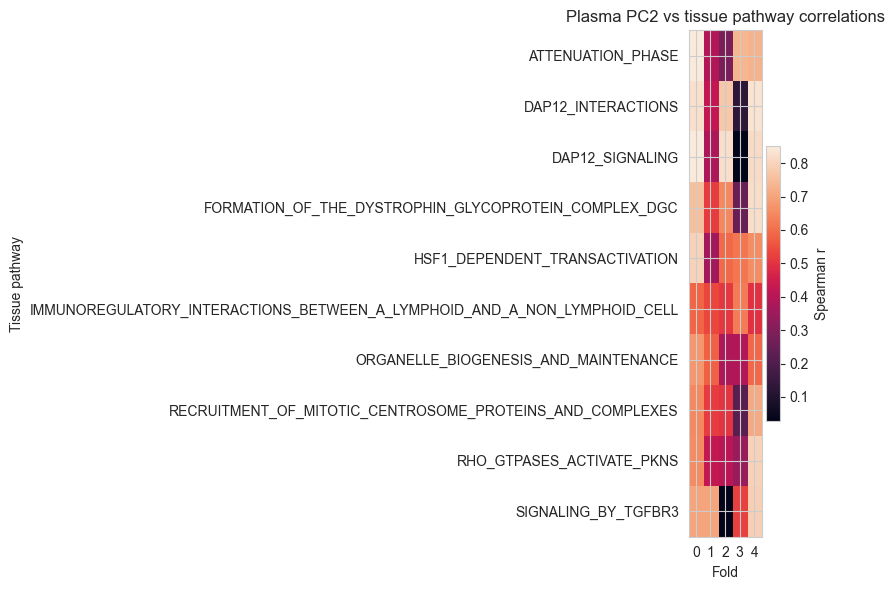

In [208]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df_PC1,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df_PC1.columns)),
    [f"{x}" for x in plot_df_PC1.columns]
)

plt.yticks(
    range(len(plot_df_PC1.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df_PC1.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

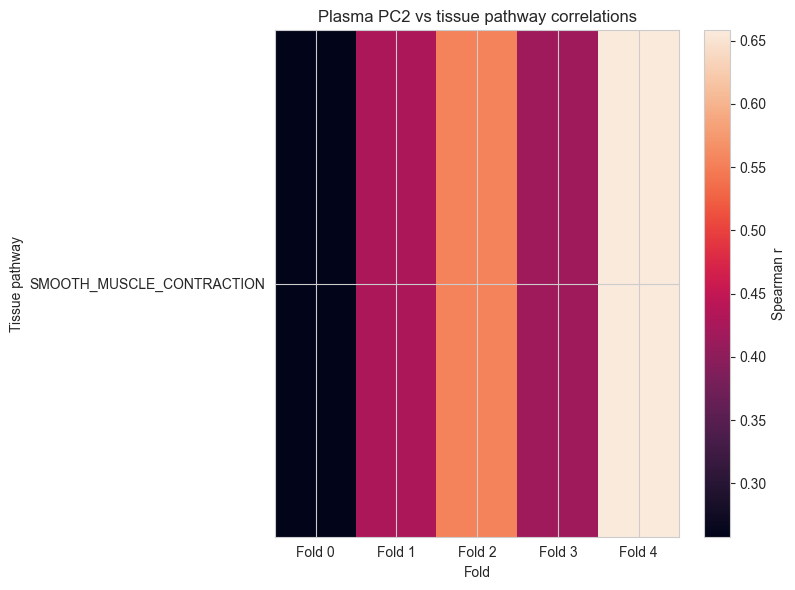

In [202]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df_PC2,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df_PC2.columns)),
    [f"Fold {x}" for x in plot_df_PC2.columns]
)

plt.yticks(
    range(len(plot_df_PC2.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df_PC2.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [203]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['spearman_mean_abs_r'],
    ascending=False
).head(30)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
902,PC2,REACTOME_CO_INHIBITION_BY_CTLA4,0.447719,0.474198,0.122358,0.681457,0.522424,0.554545,0.393939,0.645455,5
840,PC2,REACTOME_BILE_ACID_AND_BILE_SALT_METABOLISM,0.343206,0.340087,0.230794,0.536164,0.446667,0.454545,0.354545,0.563636,5
1119,PC2,REACTOME_INTRACELLULAR_SIGNALING_BY_SECOND_MES...,0.368127,0.279579,0.156928,0.620045,0.421212,0.290909,0.200000,0.754545,5
1354,PC2,REACTOME_RET_SIGNALING,0.406587,0.327866,0.004249,0.820535,0.421212,0.309091,0.045455,0.842424,5
1146,PC2,REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,0.357761,0.398369,0.025620,0.552784,0.418182,0.454545,0.078788,0.590909,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.410061,0.485561,0.082424,0.669670,0.415758,0.409091,0.100000,0.636364,5
1500,PC2,REACTOME_SYNTHESIS_OF_BILE_ACIDS_AND_BILE_SALTS,0.336824,0.273782,0.246643,0.529237,0.414545,0.406061,0.272727,0.503030,5
1144,PC2,REACTOME_MAPK1_MAPK3_SIGNALING,0.395935,0.418406,0.137660,0.571468,0.413939,0.445455,0.115152,0.600000,5
1097,PC2,REACTOME_INOSITOL_PHOSPHATE_METABOLISM,0.344450,0.310907,0.001742,0.608487,0.403030,0.478788,0.000000,0.627273,5
1224,PC2,REACTOME_NRAGE_SIGNALS_DEATH_THROUGH_JNK,0.438573,0.445220,0.070897,0.772833,0.396364,0.318182,0.154545,0.757576,5


In [204]:
cross_tissue_to_plasma[
    cross_tissue_to_plasma["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_r'],
    ascending=True
).head(50)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
1703,PC2,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,10,0.944324,0.000039,0.939394,0.000055,2,0.001054,0.005150
1859,PC2,REACTOME_SIGNALING_BY_NTRKS,10,-0.940731,0.000050,-0.939394,0.000055,2,0.001172,0.005150
1854,PC2,REACTOME_SIGNALING_BY_INTERLEUKINS,10,-0.920976,0.000155,-0.927273,0.000112,2,0.002396,0.006457
2250,PC2,REACTOME_BIOLOGICAL_OXIDATIONS,10,0.916327,0.000194,0.927273,0.000112,3,0.002753,0.006457
1620,PC2,REACTOME_CDC42_GTPASE_CYCLE,10,-0.913232,0.000223,-0.903030,0.000344,2,0.003035,0.010374
1783,PC2,REACTOME_PLASMA_LIPOPROTEIN_ASSEMBLY_REMODELIN...,10,0.912315,0.000232,0.915152,0.000204,2,0.003135,0.008879
2313,PC2,REACTOME_ECM_PROTEOGLYCANS,10,-0.905156,0.000315,-0.878788,0.000814,3,0.003982,0.014494
1670,PC2,REACTOME_DISEASES_OF_HEMOSTASIS,10,0.903943,0.000331,0.830303,0.002940,2,0.004141,0.028767
1640,PC2,REACTOME_COMPLEMENT_CASCADE,10,0.903559,0.000336,0.806061,0.004862,2,0.004161,0.037684
1724,PC2,REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT,10,0.903679,0.000335,0.890909,0.000542,2,0.004161,0.013102


In [205]:
cross_tissue_to_plasma.columns

Index(['PC', 'pathway', 'n', 'pearson_r', 'pearson_p', 'spearman_r',
       'spearman_p', 'fold', 'pearson_fdr', 'spearman_fdr'],
      dtype='str')

In [206]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    "pearson_r",
    ascending=True
).head(20)

,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7650,PC2,REACTOME_RET_SIGNALING,10,-0.820535,0.003632,-0.842424,0.002220,4,0.878549,0.503401
7130,PC2,REACTOME_AUTOPHAGY,10,-0.816373,0.003960,-0.696970,0.025097,4,0.878549,0.834674
7663,PC2,REACTOME_RHOU_GTPASE_CYCLE,10,-0.814104,0.004147,-0.769697,0.009222,4,0.878549,0.667892
1429,PC2,REACTOME_SIGNALING_BY_BRAF_AND_RAF1_FUSIONS,11,-0.791041,0.003736,-0.672727,0.023313,0,0.878549,0.834674
7768,PC2,REACTOME_SIGNALING_BY_TYPE_1_INSULIN_LIKE_GROW...,10,-0.774330,0.008554,-0.793939,0.006100,4,0.878549,0.613177
2837,PC2,REACTOME_PI_METABOLISM,11,-0.760414,0.006591,-0.636364,0.035287,1,0.878549,0.907158
7475,PC2,REACTOME_MITOPHAGY,10,-0.749015,0.012659,-0.842424,0.002220,4,0.878549,0.503401
7426,PC2,REACTOME_IRS_MEDIATED_SIGNALLING,10,-0.748320,0.012788,-0.757576,0.011143,4,0.878549,0.683590
7769,PC2,REACTOME_SIGNALING_BY_VEGF,10,-0.744682,0.013479,-0.696970,0.025097,4,0.878549,0.834674
2448,PC2,REACTOME_CHOLESTEROL_BIOSYNTHESIS,11,-0.735574,0.009879,-0.763636,0.006233,1,0.878549,0.613177
